In [1]:
ML_DATA_PATH = './../data/ml_data.csv'
ML_DATA_TRAIN_PATH = './../data/ml_data_train.csv'
ML_DATA_VAL_PATH = './../data/ml_data_val.csv'
ML_DATA_TEST_PATH = './../data/ml_data_test.csv'
ML_WEIGHTS_PATH = './../utils/initial_pos_weights.json'
import sqlite3
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.python.client import device_lib
import os
import sys
from collections import Counter
from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Input, BatchNormalization, Activation, Add, LeakyReLU
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras import layers
from tensorflow.keras.applications import InceptionResNetV2, VGG16, MobileNetV2
from tensorflow.keras.utils import to_categorical
from PIL import Image
import requests
import zipfile

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output as cls
from keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler
import pandas as pd
import PIL

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from pathlib import Path
import statistics
import ast
import json
import statistics

import glob
import cv2
from PIL import Image
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

module_path = os.path.abspath(os.path.join('..', 'utils'))
if module_path not in sys.path:
    sys.path.append(module_path)

from utils2 import DataGenerator, plot_graph, bar_plot, two_bar_plot, StepwiseLogger

In [2]:
read_size = 2048
batch_size = 32
num_classes = 64
train_data_generator = DataGenerator(ML_DATA_TRAIN_PATH, read_size, batch_size, num_classes, 27913)
val_data_generator = DataGenerator(ML_DATA_VAL_PATH, read_size, batch_size, num_classes, 3102)
test_data_generator = DataGenerator(ML_DATA_TEST_PATH, read_size, batch_size, num_classes, 3447)

In [3]:
def create_model(input_shape):
    inputs = Input(shape=input_shape)

    x1 = Conv2D(8, (3, 3), padding='same', activation='sigmoid')(inputs)
    x1 = BatchNormalization()(x1)
    x1 = Dropout(0.2)(x1)
    
    x2 = Conv2D(32, (3, 3), padding='same', activation='sigmoid')(x1)
    x2 = BatchNormalization()(x2)
    x2 = Dropout(0.2)(x2)
    
    x3 = Conv2D(64, (3, 3), padding='same', activation='sigmoid')(x2)
    x3 = BatchNormalization()(x3)
    x3 = Dropout(0.2)(x3)

    xtop = Flatten()(x3)
    xtop = Dense(256, activation='sigmoid')(xtop)
    xtop = Dropout(0.2)(xtop)
    xtop = Dense(128, activation='sigmoid')(xtop)
    xtop = Dropout(0.2)(xtop)

    predictions = Dense(64, activation='softmax')(xtop)

    model = Model(inputs=inputs, outputs=predictions)
    return model

In [4]:
INPUT_SHAPE = (8, 8, 6)
model = create_model(INPUT_SHAPE)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 8, 8, 6)]         0         
                                                                 
 conv2d (Conv2D)             (None, 8, 8, 8)           440       
                                                                 
 batch_normalization (BatchN  (None, 8, 8, 8)          32        
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 8, 8, 8)           0         
                                                                 
 conv2d_1 (Conv2D)           (None, 8, 8, 32)          2336      
                                                                 
 batch_normalization_1 (Batc  (None, 8, 8, 32)         128       
 hNormalization)                                             

In [5]:
model.compile(optimizer='Adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [6]:
steps_per_epoch_val = len(val_data_generator)
stepwise_logger = StepwiseLogger(val_data_generator, steps_per_epoch_val, 200)

In [7]:
test_df = pd.read_csv(ML_DATA_TEST_PATH)

In [8]:
loaded_class_weights_dict = class_weights = compute_class_weight('balanced', classes=np.unique(test_df['initial_pos']), y=test_df['initial_pos'])
class_weights_dict = {cls: weight for cls, weight in zip(np.unique(test_df['initial_pos']), class_weights)}

In [275]:
encoded_weights = {}
for key in class_weights_dict.keys():
    encoded_weights[test_data_generator.encode_pos([key])[0]] = class_weights_dict.get(key)

In [276]:
history = model.fit(train_data_generator, epochs=20, validation_data=val_data_generator, shuffle=False, callbacks=[stepwise_logger, EarlyStopping(patience=5, restore_best_weights=True)], class_weight=encoded_weights)

Epoch 1/20
873/873 [==============================] - 9s 9ms/step - loss: 3.0734 - accuracy: 0.1679 - val_loss: 3.3203 - val_accuracy: 0.1534
Epoch 2/20
873/873 [==============================] - 7s 8ms/step - loss: 2.2610 - accuracy: 0.2814 - val_loss: 2.8285 - val_accuracy: 0.2853
Epoch 3/20
873/873 [==============================] - 8s 9ms/step - loss: 2.0701 - accuracy: 0.2905 - val_loss: 2.6777 - val_accuracy: 0.2946
Epoch 4/20
873/873 [==============================] - 7s 8ms/step - loss: 1.9261 - accuracy: 0.3012 - val_loss: 2.5556 - val_accuracy: 0.3046
Epoch 5/20
873/873 [==============================] - 7s 8ms/step - loss: 1.8159 - accuracy: 0.3217 - val_loss: 2.4882 - val_accuracy: 0.3108
Epoch 6/20
873/873 [==============================] - 7s 8ms/step - loss: 1.8073 - accuracy: 0.3247 - val_loss: 2.4465 - val_accuracy: 0.3124
Epoch 7/20
873/873 [==============================] - 7s 8ms/step - loss: 1.7200 - accuracy: 0.3338 - val_loss: 2.4359 - val_accuracy: 0.3398
Epoch 

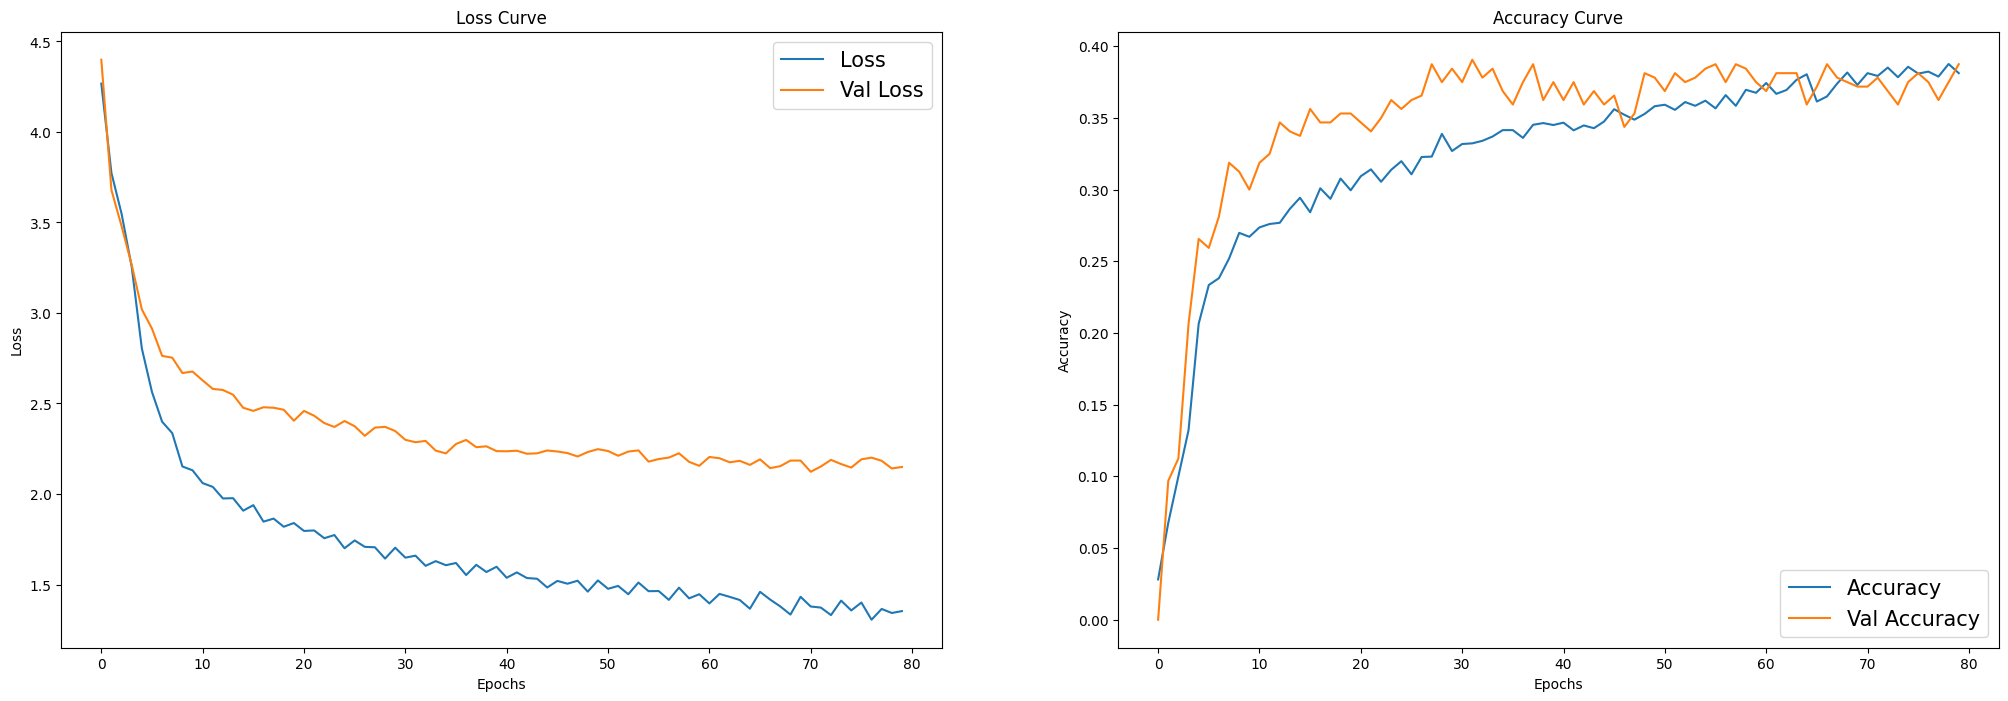

In [277]:
plot_graph(history=stepwise_logger)

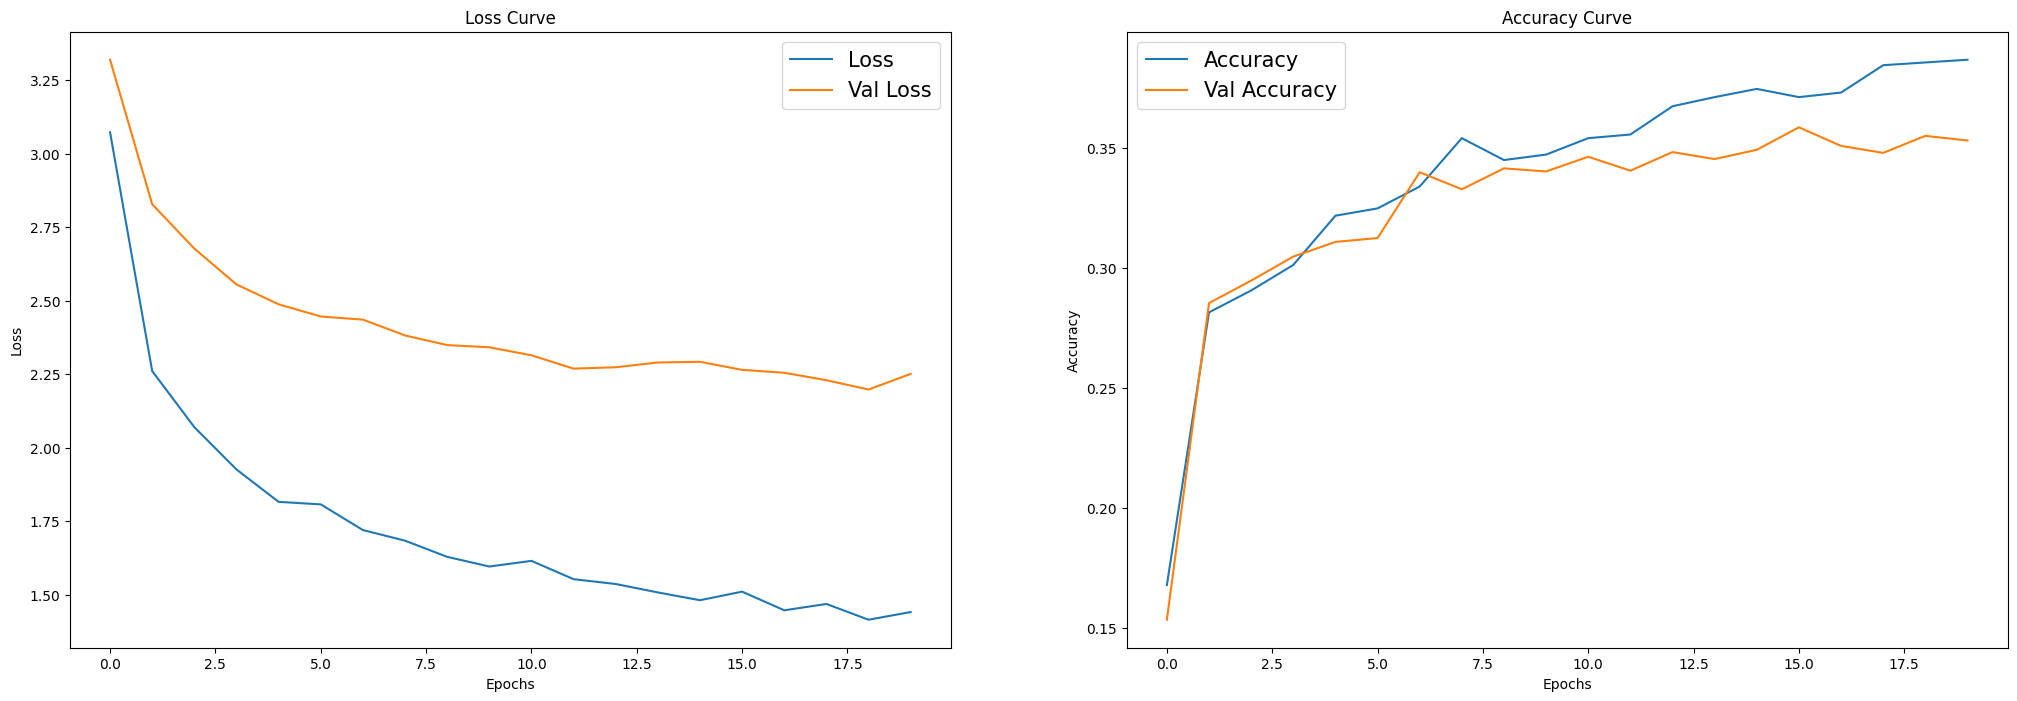

In [278]:
plot_graph(history=history)

In [279]:
model.evaluate(test_data_generator)

108/108 [==============================] - 1s 12ms/step - loss: 2.2592 - accuracy: 0.3650


[2.259176015853882, 0.36495503783226013]

In [280]:
predictions = model.predict(test_data_generator)
predictions = np.argmax(predictions,axis=1)
group_predictions = np.unique(predictions, return_counts=True)

108/108 [==============================] - 1s 5ms/step


In [233]:
def decode_pos(positions):
        number_to_column = {
            1 : 'a',
            2 : 'b',
            3 : 'c',
            4 : 'd',
            5 : 'e',
            6 : 'f',
            7 : 'g',
            8 : 'h'
        }
        decoded_positions = []
        for pos in positions:
            decoded_pos = number_to_column.get(pos % 8 + 1) + str(8 - (pos // 8))
            decoded_positions.append(decoded_pos)
        return np.array(decoded_positions)

In [234]:
test_df = pd.read_csv(ML_DATA_TEST_PATH)

In [281]:
f1_scores = f1_score(test_df['initial_pos'], decode_pos(predictions), average=None)

In [282]:
f1_score(test_df['initial_pos'], decode_pos(predictions), average='weighted')

0.3403887852249004

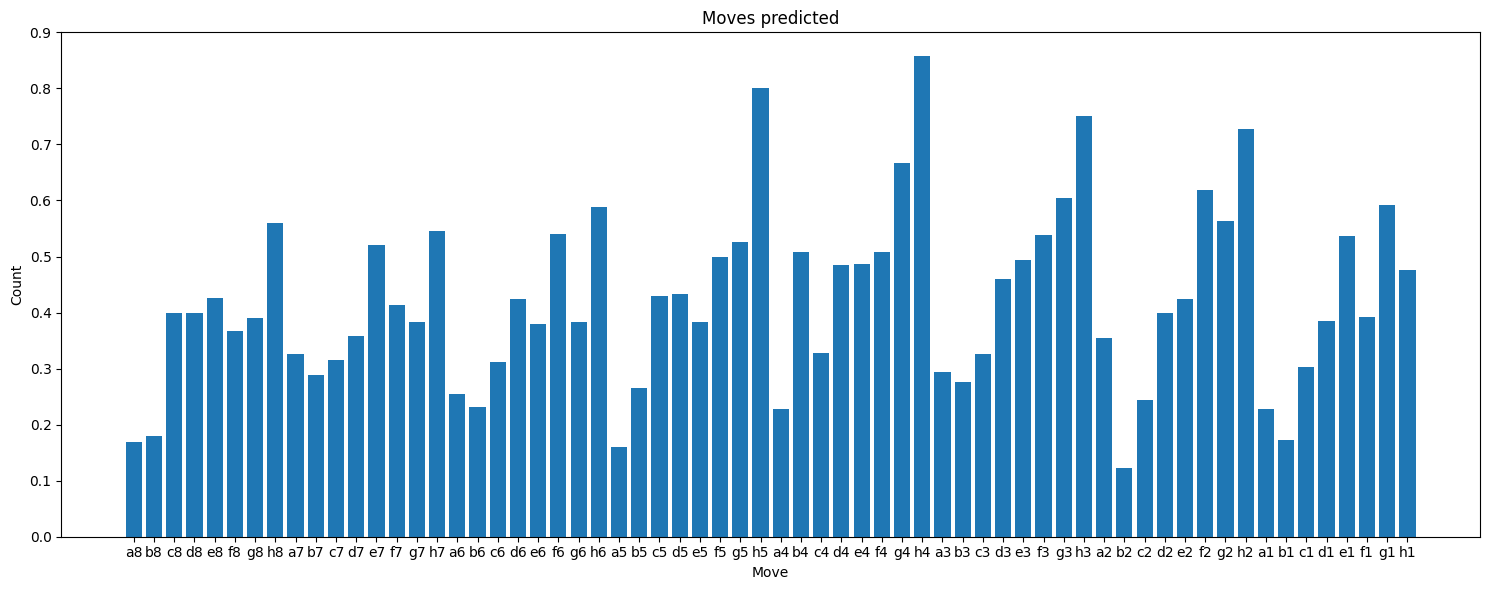

In [283]:
bar_plot(decode_pos(group_predictions[0]), f1_scores)

In [251]:
INPUT_SHAPE = (8, 8, 6)
model2 = create_model(INPUT_SHAPE)
model2.compile(optimizer='Adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model2.fit(train_data_generator, epochs=20, validation_data=val_data_generator, shuffle=False, callbacks=[stepwise_logger, EarlyStopping(patience=5, restore_best_weights=True)])

Epoch 1/20
873/873 [==============================] - 9s 9ms/step - loss: 2.9734 - accuracy: 0.2378 - val_loss: 2.8605 - val_accuracy: 0.2521
Epoch 2/20
873/873 [==============================] - 8s 9ms/step - loss: 2.6332 - accuracy: 0.2837 - val_loss: 2.5239 - val_accuracy: 0.2930
Epoch 3/20
873/873 [==============================] - 8s 9ms/step - loss: 2.4594 - accuracy: 0.3145 - val_loss: 2.3410 - val_accuracy: 0.3246
Epoch 4/20
873/873 [==============================] - 8s 9ms/step - loss: 2.3179 - accuracy: 0.3346 - val_loss: 2.2406 - val_accuracy: 0.3375
Epoch 5/20
873/873 [==============================] - 8s 9ms/step - loss: 2.2077 - accuracy: 0.3570 - val_loss: 2.1528 - val_accuracy: 0.3453
Epoch 6/20
873/873 [==============================] - 8s 9ms/step - loss: 2.1653 - accuracy: 0.3483 - val_loss: 2.0935 - val_accuracy: 0.3604
Epoch 7/20
873/873 [==============================] - 8s 10ms/step - loss: 2.0840 - accuracy: 0.3806 - val_loss: 2.0490 - val_accuracy: 0.3704
Epoch

In [252]:
model2.evaluate(test_data_generator)

108/108 [==============================] - 1s 5ms/step - loss: 1.9495 - accuracy: 0.3827


[1.949488878250122, 0.38265156745910645]

In [253]:
predictions2 = model2.predict(test_data_generator)
predictions2 = np.argmax(predictions2,axis=1)
group_predictions2 = np.unique(predictions2, return_counts=True)

108/108 [==============================] - 1s 5ms/step


In [254]:
f1_scores2 = f1_score(test_df['initial_pos'], decode_pos(predictions2), average=None)

In [255]:
f1_score(test_df['initial_pos'], decode_pos(predictions2), average='weighted')

0.36745625422718786

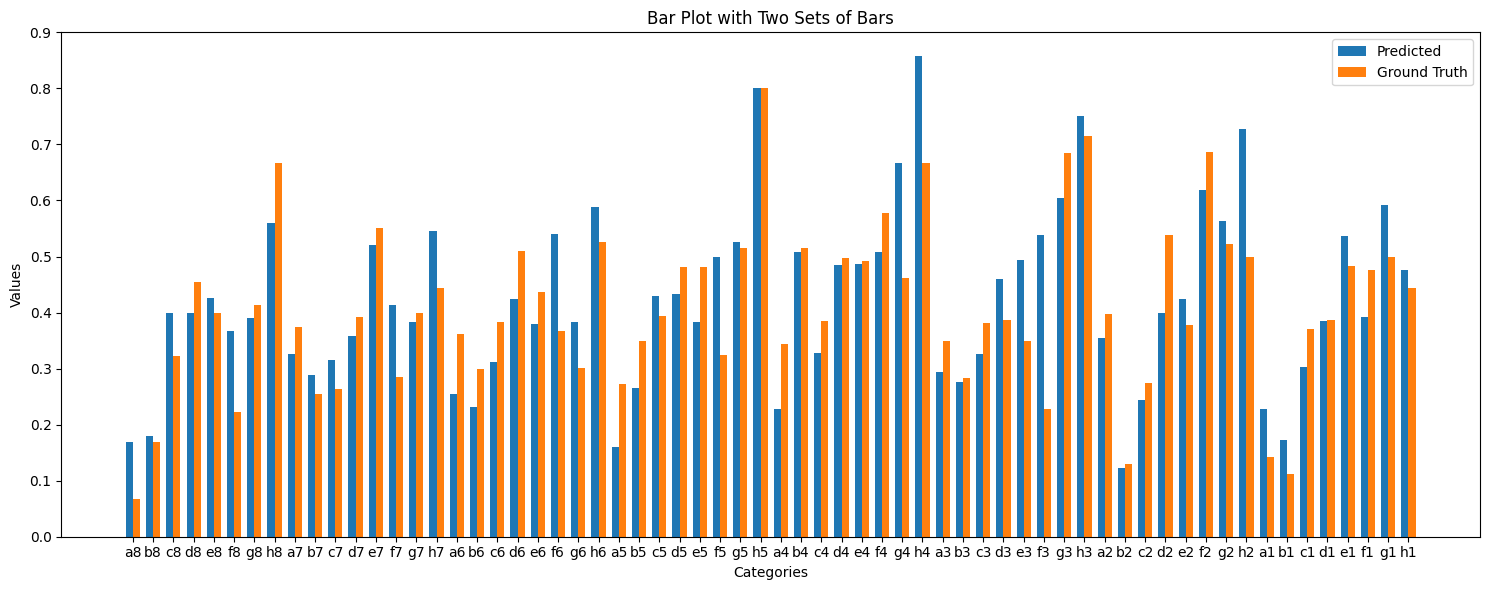

In [285]:
two_bar_plot(decode_pos(group_predictions[0]), f1_scores, f1_scores2)

In [298]:
statistics.mean(f1_scores)

0.42188093926074277

In [299]:
statistics.mean(f1_scores2)

0.408537361493735

In [294]:
statistics.stdev(f1_scores)

0.15728276739440114

In [295]:
statistics.stdev(f1_scores2)

0.1475032493266001